<a href="https://colab.research.google.com/github/EfekanSalman/Mental-Confusion-Prediction/blob/main/Mental_Confusion_Prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import kagglehub
path = kagglehub.dataset_download("wanghaohan/confused-eeg")

100%|██████████| 109M/109M [00:00<00:00, 176MB/s] 

Extracting files...


In [12]:
import pandas as pd
import os

# List files in the dataset
for root, dirs, files in os.walk(path):
    for file in files:
        print(os.path.join(root, file))

# Let's load the main data file as an example (you can update the file name according to the output above)
# Usually, it would be 'EEG_data.csv' or a similar name
data_path = os.path.join(path, 'EEG_data.csv')
if os.path.exists(data_path):
    df = pd.read_csv(data_path)
    display(df.head())
    display(df.info())
else:
    print('Main data file not found, please select a file from the list above.')

/root/.cache/kagglehub/datasets/wanghaohan/confused-eeg/versions/6/EEG_data.csv
/root/.cache/kagglehub/datasets/wanghaohan/confused-eeg/versions/6/demographic_info.csv
/root/.cache/kagglehub/datasets/wanghaohan/confused-eeg/versions/6/videos/0.m4v
/root/.cache/kagglehub/datasets/wanghaohan/confused-eeg/versions/6/videos/4.m4v
/root/.cache/kagglehub/datasets/wanghaohan/confused-eeg/versions/6/videos/7.m4v
/root/.cache/kagglehub/datasets/wanghaohan/confused-eeg/versions/6/videos/2.m4v
/root/.cache/kagglehub/datasets/wanghaohan/confused-eeg/versions/6/videos/8.m4v
/root/.cache/kagglehub/datasets/wanghaohan/confused-eeg/versions/6/videos/5.m4v
/root/.cache/kagglehub/datasets/wanghaohan/confused-eeg/versions/6/videos/3.m4v
/root/.cache/kagglehub/datasets/wanghaohan/confused-eeg/versions/6/videos/6.m4v
/root/.cache/kagglehub/datasets/wanghaohan/confused-eeg/versions/6/videos/1.m4v
/root/.cache/kagglehub/datasets/wanghaohan/confused-eeg/versions/6/videos/9.m4v


,SubjectID,VideoID,Attention,Mediation,Raw,Delta,Theta,Alpha1,Alpha2,Beta1,Beta2,Gamma1,Gamma2,predefinedlabel,user-definedlabeln
0,0.0,0.0,56.0,43.0,278.0,301963.0,90612.0,33735.0,23991.0,27946.0,45097.0,33228.0,8293.0,0.0,0.0
1,0.0,0.0,40.0,35.0,-50.0,73787.0,28083.0,1439.0,2240.0,2746.0,3687.0,5293.0,2740.0,0.0,0.0
2,0.0,0.0,47.0,48.0,101.0,758353.0,383745.0,201999.0,62107.0,36293.0,130536.0,57243.0,25354.0,0.0,0.0
3,0.0,0.0,47.0,57.0,-5.0,2012240.0,129350.0,61236.0,17084.0,11488.0,62462.0,49960.0,33932.0,0.0,0.0
4,0.0,0.0,44.0,53.0,-8.0,1005145.0,354328.0,37102.0,88881.0,45307.0,99603.0,44790.0,29749.0,0.0,0.0


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12811 entries, 0 to 12810
Data columns (total 15 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   SubjectID           12811 non-null  float64
 1   VideoID             12811 non-null  float64
 2   Attention           12811 non-null  float64
 3   Mediation           12811 non-null  float64
 4   Raw                 12811 non-null  float64
 5   Delta               12811 non-null  float64
 6   Theta               12811 non-null  float64
 7   Alpha1              12811 non-null  float64
 8   Alpha2              12811 non-null  float64
 9   Beta1               12811 non-null  float64
 10  Beta2               12811 non-null  float64
 11  Gamma1              12811 non-null  float64
 12  Gamma2              12811 non-null  float64
 13  predefinedlabel     12811 non-null  float64
 14  user-definedlabeln  12811 non-null  float64
dtypes: float64(15)
memory usage: 1.5 MB


None

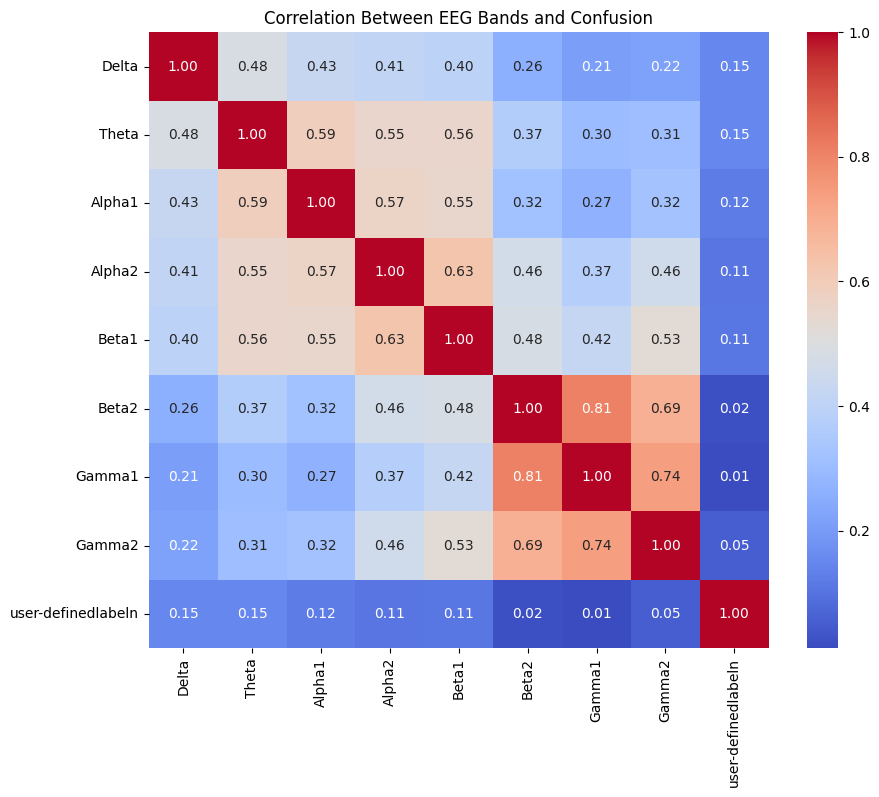

Correlation Ranking with Confusion (user-definedlabeln):
user-definedlabeln    1.000000
Delta                 0.148588
Theta                 0.147558
Alpha1                0.121711
Beta1                 0.111482
Alpha2                0.107238
Gamma2                0.053533
Beta2                 0.019556
Gamma1                0.011316
Name: user-definedlabeln, dtype: float64


In [13]:
import seaborn as sns
import matplotlib.pyplot as plt

# Calculate the correlation matrix
# Let's select frequency bands and the target variable
eeg_bands = ['Delta', 'Theta', 'Alpha1', 'Alpha2', 'Beta1', 'Beta2', 'Gamma1', 'Gamma2', 'user-definedlabeln']
corr_matrix = df[eeg_bands].corr()

# Visualize the correlation
plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Between EEG Bands and Confusion')
plt.show()

# Show the correlation with confusion sorted
print("Correlation Ranking with Confusion (user-definedlabeln):")
print(corr_matrix['user-definedlabeln'].sort_values(ascending=False))

In [14]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, accuracy_score

# Define features (X) and target variable (y)
# This time, we also add 'Attention' and 'Mediation' columns
features = ['Delta', 'Theta', 'Alpha1', 'Alpha2', 'Beta1', 'Beta2', 'Gamma1', 'Gamma2', 'Attention', 'Mediation']
X = df[features]
y = df['user-definedlabeln']

# Split the data into training (80%) and test (20%) sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Create and train the Random Forest model
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)

# Make predictions
y_pred = rf_model.predict(X_test)

# Evaluate the results
print(f'Improved Model Accuracy: {accuracy_score(y_test, y_pred):.4f}')
print('\nClassification Report:')
print(classification_report(y_test, y_pred))

Improved Model Accuracy: 0.6660

Classification Report:
              precision    recall  f1-score   support

         0.0       0.68      0.64      0.66      1298
         1.0       0.65      0.69      0.67      1265

    accuracy                           0.67      2563
   macro avg       0.67      0.67      0.67      2563
weighted avg       0.67      0.67      0.67      2563



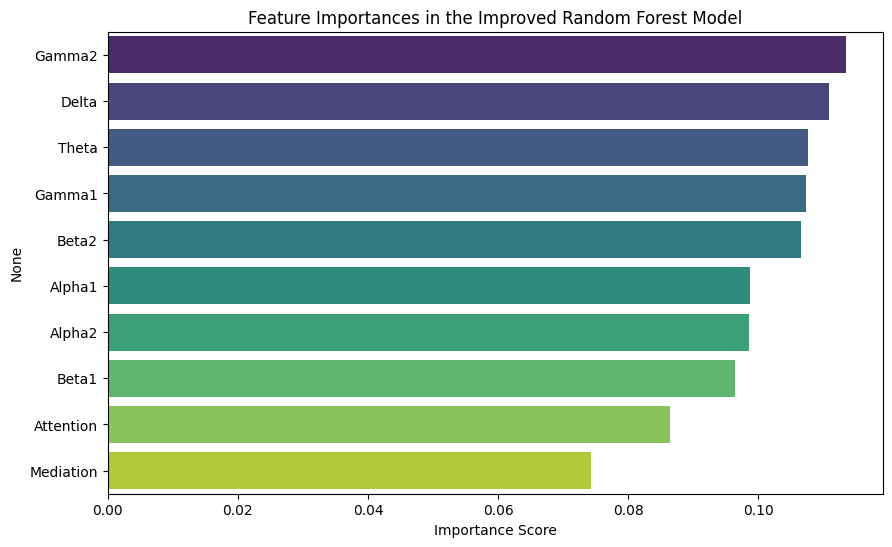

In [15]:
# Visualize feature importances
feature_importance = pd.Series(rf_model.feature_importances_, index=features).sort_values(ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(x=feature_importance, y=feature_importance.index, hue=feature_importance.index, palette='viridis', legend=False)
plt.title('Feature Importances in the Improved Random Forest Model')
plt.xlabel('Importance Score')
plt.show()

In [6]:
from sklearn.model_selection import GridSearchCV

# Define the parameter grid to explore
param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [None, 10, 20, 30],
    'min_samples_split': [2, 5, 10],
    'random_state': [42]
}

# Initialize GridSearchCV
grid_search = GridSearchCV(estimator=RandomForestClassifier(),
                           param_grid=param_grid,
                           cv=5,
                           n_jobs=-1,
                           verbose=1,
                           scoring='accuracy')

# Fit the grid search to the data
print("Searching for the best hyperparameters...")
grid_search.fit(X_train, y_train)

# Best parameters and best score
print(f"Best Parameters: {grid_search.best_params_}")
print(f"Best Cross-validation Accuracy: {grid_search.best_score_:.4f}")

Searching for the best hyperparameters...
Fitting 5 folds for each of 36 candidates, totalling 180 fits
Best Parameters: {'max_depth': None, 'min_samples_split': 10, 'n_estimators': 200, 'random_state': 42}
Best Cross-validation Accuracy: 0.6549


In [16]:
# Evaluate the best model on the test set
best_rf_model = grid_search.best_estimator_
y_pred_optimized = best_rf_model.predict(X_test)

print(f'Optimized Model Test Accuracy: {accuracy_score(y_test, y_pred_optimized):.4f}')
print('\nOptimized Classification Report:')
print(classification_report(y_test, y_pred_optimized))

Optimized Model Test Accuracy: 0.6719

Optimized Classification Report:
              precision    recall  f1-score   support

         0.0       0.69      0.63      0.66      1298
         1.0       0.65      0.71      0.68      1265

    accuracy                           0.67      2563
   macro avg       0.67      0.67      0.67      2563
weighted avg       0.67      0.67      0.67      2563



In [17]:
!pip install xgboost
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, classification_report

# Define and train the XGBoost model
xgb_model = XGBClassifier(n_estimators=100, learning_rate=0.1, max_depth=6, random_state=42, use_label_encoder=False, eval_metric='logloss')
xgb_model.fit(X_train, y_train)

# Make predictions
y_pred_xgb = xgb_model.predict(X_test)

# Evaluate the results
print(f'XGBoost Model Accuracy: {accuracy_score(y_test, y_pred_xgb):.4f}')
print('\nXGBoost Classification Report:')
print(classification_report(y_test, y_pred_xgb))

XGBoost Model Accuracy: 0.6703

XGBoost Classification Report:
              precision    recall  f1-score   support

         0.0       0.69      0.64      0.66      1298
         1.0       0.66      0.70      0.68      1265

    accuracy                           0.67      2563
   macro avg       0.67      0.67      0.67      2563
weighted avg       0.67      0.67      0.67      2563



/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [18:36:32] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


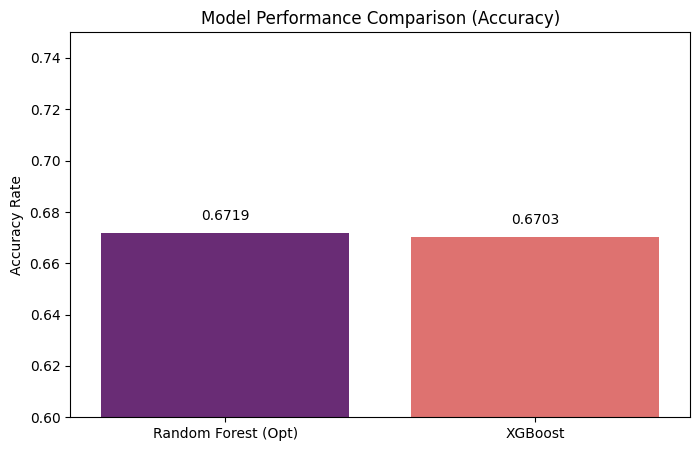

In [18]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from sklearn.metrics import accuracy_score

# Compare the accuracy of the two models
models = ['Random Forest (Opt)', 'XGBoost']
accuracies = [accuracy_score(y_test, y_pred_optimized), accuracy_score(y_test, y_pred_xgb)]

plt.figure(figsize=(8, 5))
sns.barplot(x=models, y=accuracies, hue=models, palette='magma', legend=False)
plt.ylim(0.6, 0.75)
plt.title('Model Performance Comparison (Accuracy)')
plt.ylabel('Accuracy Rate')

for i, val in enumerate(accuracies):
    plt.text(i, val + 0.005, f'{val:.4f}', ha='center')

plt.show()